Step 1

In [2]:
import pandas as pd

# Load the Excel file
file_path = '/Users/sam/Documents/DI_DATA_2025/week9/day4/US Superstore data.xls'
df = pd.read_excel(file_path)

# Display first rows and info
print(df.head())
print(df.info())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [3]:
# Check for missing values
print(df.isnull().sum())

# Example cleaning steps (adapter selon les données) :

# Remove duplicates if any
df = df.drop_duplicates()

# Convert date column to datetime type (change 'Order Date' par le nom exact de ta colonne)
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Drop rows where 'Order Date' couldn't be converted (if any)
df = df.dropna(subset=['Order Date'])

# Add a 'Year' column for trend analysis
df['Year'] = df['Order Date'].dt.year

# Check again after cleaning
print(df.info())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        99

Step 2

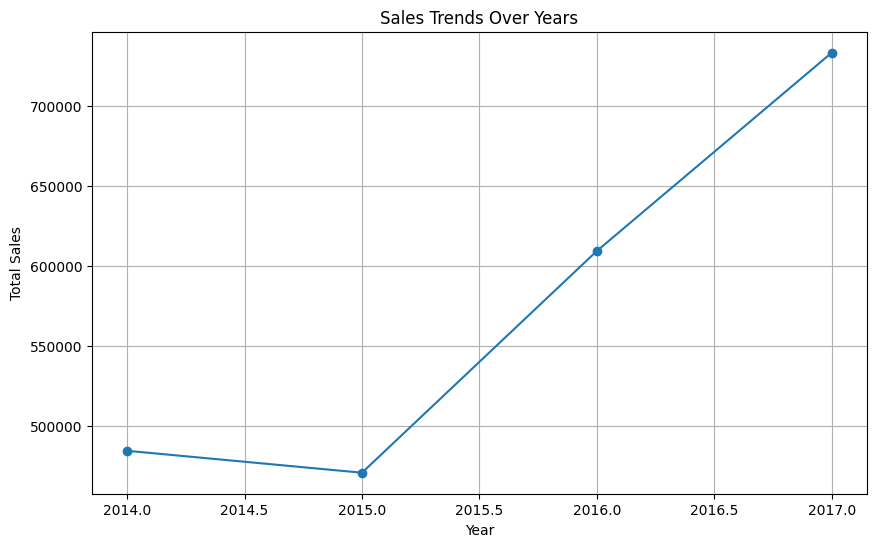

In [4]:
import matplotlib.pyplot as plt

# Aggregate total sales per year
sales_by_year = df.groupby('Year')['Sales'].sum().reset_index()

# Plot
plt.figure(figsize=(10,6))
plt.plot(sales_by_year['Year'], sales_by_year['Sales'], marker='o')
plt.title('Sales Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [5]:
import plotly.express as px

# Aggregate sales by country (adjust column name if needed)
sales_by_country = df.groupby('Country')['Sales'].sum().reset_index()

fig = px.choropleth(sales_by_country, locations='Country',
                    locationmode='country names',
                    color='Sales',
                    color_continuous_scale='Viridis',
                    title='Sales Distribution by Country')

fig.show()

Step 3

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_67083/2792967230.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




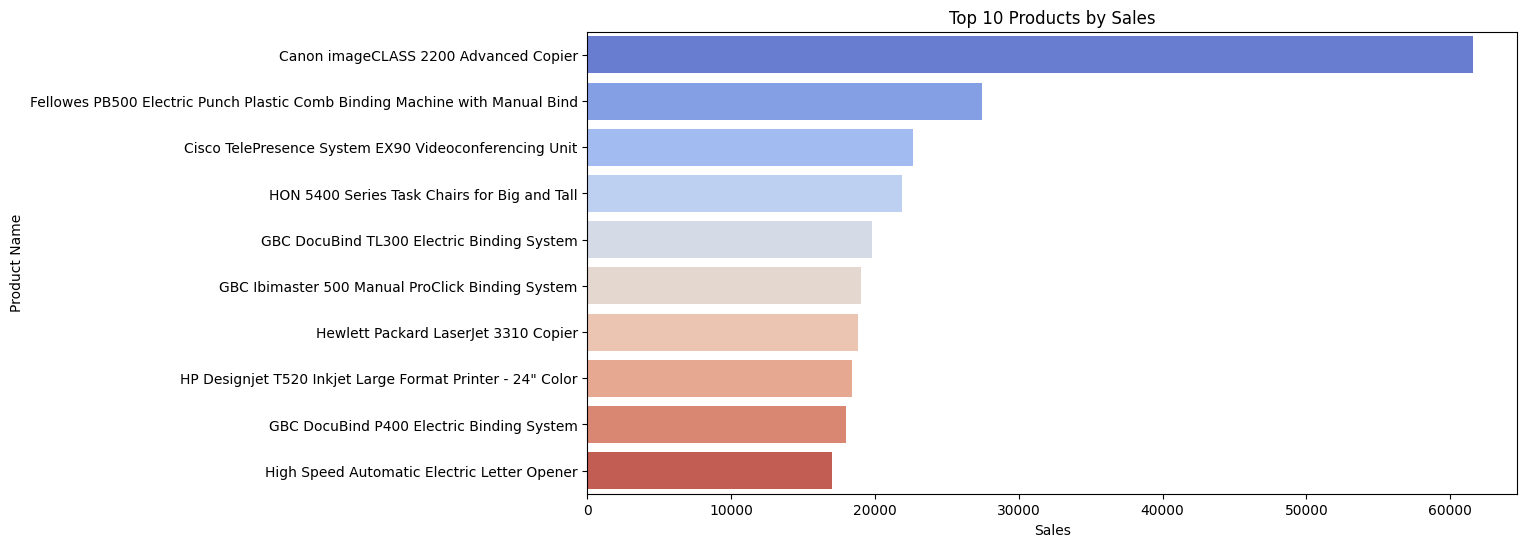

In [6]:
import seaborn as sns

# Top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_products, x='Sales', y='Product Name', palette='coolwarm')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')
plt.show()

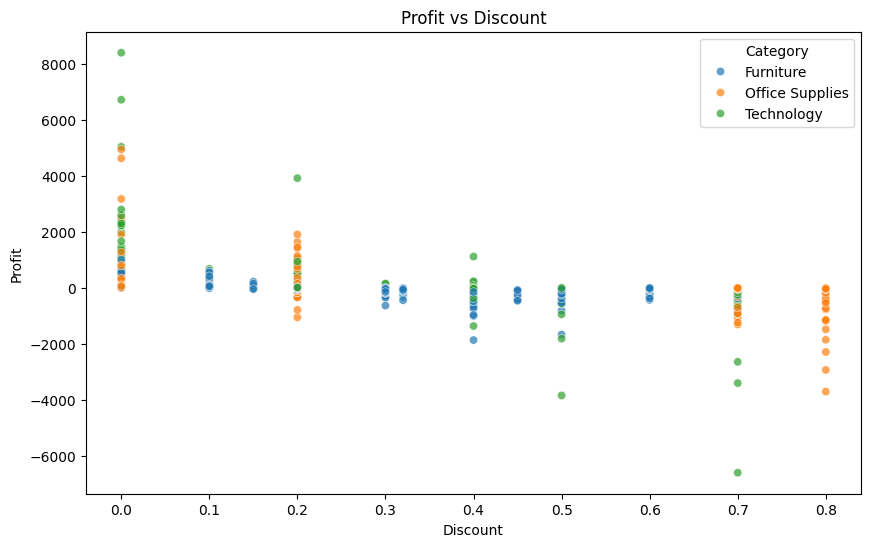

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.7)
plt.title('Profit vs Discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

Step 4 : 

Comparative Analysis: Matplotlib vs Seaborn
Matplotlib offers fine-grained control but requires more code to create styled plots.

Seaborn is more expressive for statistical visualizations and comes with attractive default styles.

For interactive charts, Plotly is often preferred.

In this exercise, Matplotlib was great for time series trends, while Seaborn made categorical comparisons easier.